# Circular Trial-Shift Null Across 5x5 Metric Pairs (SEEG)

## Goal

Test whether observed pre-stimulus to post-stimulus coupling across the 5x5 metric-pair space is specific to correct trial pairing, rather than explained by slow within-session drift or autocorrelation.

## Null Hypothesis

For each session and each metric pair, compare the observed correlation between correctly paired trials to a null distribution obtained by circularly shifting the pre-stimulus trial order relative to the post-stimulus trial order.

1. Observed: $r_{obs} = \mathrm{corr}(pre_i, post_i)$
2. Null: $r_k = \mathrm{corr}(pre_{i+k \; \mathrm{mod} \; N}, post_i)$ for shifts $k = 1, \dots, N-1$
3. P-value: fraction of shifted correlations whose absolute value is greater than or equal to $|r_{obs}|$

## Interpretation

- Small p-values indicate that correct trial pairing carries information beyond slow temporal drift, regardless of whether the coupling is positive or negative.
- The main summary figure uses two heatmaps only:
  - Mean $|r_{obs}| - \overline{|r|}_{null}$ across sessions
  - Percentage of sessions with p < 0.05

## Scope

- Modality: SEEG
- Metrics: ZCR, Salience, Entrainment, Fluidity, Complexity
- Spatial filter: radius_pre = 100, radius_post = 100
- Unit of analysis: session × metric pair

In [34]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import pearsonr

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['font.size'] = 10

In [35]:
METRICS_5_ORDER = [
    'zero_crossing_rate',
    'salience',
    'phase_coherence_matrix_mean_mat',
    'dynamic_functional_connectivity_matrix_var_mat',
    'Entropy_FC',
]

METRICS_5_LABELS = [
    'ZCR',
    'Salience',
    'Entrainment',
    'Fluidity',
    'Complexity',
]

METRIC_LABEL_MAP = dict(zip(METRICS_5_ORDER, METRICS_5_LABELS))
metric_order = METRICS_5_LABELS

print(f'Analyzing {len(METRICS_5_ORDER)} metrics and {len(METRICS_5_ORDER) ** 2} metric pairs per session.')

Analyzing 5 metrics and 25 metric pairs per session.


In [36]:
cwd = Path.cwd().resolve()
if (cwd / 'data').exists():
    project_root = cwd
elif (cwd.parent / 'data').exists():
    project_root = cwd.parent
else:
    raise FileNotFoundError('Could not find project root containing data/.')

metrics_root = project_root / 'data' / 'df_results' / 'ieeg_metrics'
results_fig_path = project_root / 'results' / 'figures'
results_fig_path.mkdir(parents=True, exist_ok=True)

csv_path = metrics_root / 'df_9MOIs_ieeg.csv'
df = pd.read_csv(csv_path)
df['metric_name'] = pd.Categorical(df['metric_name'], categories=METRICS_5_ORDER, ordered=True)
df = df[(df['radius_pre'] == 100) & (df['radius_post'] == 100)].copy()

print(f'Loaded: {csv_path}')
print(f'Data shape after radius filtering: {df.shape}')
print(f'Unique subjects: {df["sub"].nunique()}')
print(f'Unique sessions: {df.groupby(["sub", "run_is"]).ngroups}')

Loaded: /Users/cbc/Documents/GitHub/fufo/notebook/DavideMomi/Revision/State_Dependent_Brain_Stimulation-main/data/df_results/ieeg_metrics/df_9MOIs_ieeg.csv
Data shape after radius filtering: (98370, 8)
Unique subjects: 36
Unique sessions: 318


In [44]:
def compute_trial_shift_null(pre_vals, post_vals):
    pre_vals = np.asarray(pre_vals).flatten()
    post_vals = np.asarray(post_vals).flatten()

    mask = ~(np.isnan(pre_vals) | np.isnan(post_vals))
    pre_vals = pre_vals[mask]
    post_vals = post_vals[mask]
    n_trials = len(pre_vals)

    if n_trials < 3:
        return {
            'r_observed': np.nan,
            'abs_r_observed': np.nan,
            'r_null_mean': np.nan,
            'abs_r_null_mean': np.nan,
            'r_null_std': np.nan,
            'r_null_min': np.nan,
            'r_null_max': np.nan,
            'p_value': np.nan,
            'n_trials': n_trials,
        }

    if np.std(pre_vals) == 0 or np.std(post_vals) == 0:
        return {
            'r_observed': np.nan,
            'abs_r_observed': np.nan,
            'r_null_mean': np.nan,
            'abs_r_null_mean': np.nan,
            'r_null_std': np.nan,
            'r_null_min': np.nan,
            'r_null_max': np.nan,
            'p_value': np.nan,
            'n_trials': n_trials,
        }

    r_observed, _ = pearsonr(pre_vals, post_vals)
    abs_r_observed = np.abs(r_observed)

    r_null = []
    for shift in range(1, n_trials):
        pre_shifted = np.roll(pre_vals, shift)
        if np.std(pre_shifted) == 0 or np.std(post_vals) == 0:
            r_k = np.nan
        else:
            r_k, _ = pearsonr(pre_shifted, post_vals)
        r_null.append(r_k)

    r_null = np.asarray(r_null, dtype=float)
    valid_null = r_null[np.isfinite(r_null)]

    if len(valid_null) == 0:
        p_value = np.nan
        r_null_mean = np.nan
        abs_r_null_mean = np.nan
        r_null_std = np.nan
        r_null_min = np.nan
        r_null_max = np.nan
    else:
        abs_valid_null = np.abs(valid_null)
        n_geq = np.sum(abs_valid_null >= abs_r_observed)
        p_value = (n_geq + 1) / (len(valid_null) + 1)
        r_null_mean = np.mean(valid_null)
        abs_r_null_mean = np.mean(abs_valid_null)
        r_null_std = np.std(valid_null)
        r_null_min = np.min(valid_null)
        r_null_max = np.max(valid_null)

    return {
        'r_observed': r_observed,
        'abs_r_observed': abs_r_observed,
        'r_null_mean': r_null_mean,
        'abs_r_null_mean': abs_r_null_mean,
        'r_null_std': r_null_std,
        'r_null_min': r_null_min,
        'r_null_max': r_null_max,
        'p_value': p_value,
        'n_trials': n_trials,
    }

print('Defined compute_trial_shift_null(pre_vals, post_vals).')

Defined compute_trial_shift_null(pre_vals, post_vals).


In [45]:
results = []
n_sessions = df.groupby(['sub', 'run_is']).ngroups
n_pairs_total = len(METRICS_5_ORDER) ** 2

print(f'Computing trial-shift nulls for {n_sessions} sessions and {n_pairs_total} metric pairs per session...')

for (sub, run), session_df in df.groupby(['sub', 'run_is']):
    session_df = session_df.sort_values('trial_id').reset_index(drop=True)
    pivot = session_df.pivot_table(
        index='trial_id',
        columns='metric_name',
        values=['metric_value_pre', 'metric_value_post'],
        aggfunc='mean',
    )

    for pre_metric in METRICS_5_ORDER:
        for post_metric in METRICS_5_ORDER:
            pre_key = ('metric_value_pre', pre_metric)
            post_key = ('metric_value_post', post_metric)

            if pre_key not in pivot.columns or post_key not in pivot.columns:
                continue

            pre_vals = pivot[pre_key].values
            post_vals = pivot[post_key].values
            null_result = compute_trial_shift_null(pre_vals, post_vals)

            results.append({
                'sub': sub,
                'run_is': run,
                'pre_metric': pre_metric,
                'post_metric': post_metric,
                'pre_metric_label': METRIC_LABEL_MAP[pre_metric],
                'post_metric_label': METRIC_LABEL_MAP[post_metric],
                **null_result,
            })

df_null_pairs = pd.DataFrame(results)
df_null_pairs['delta_abs_r'] = df_null_pairs['abs_r_observed'] - df_null_pairs['abs_r_null_mean']
df_null_pairs['significant'] = df_null_pairs['p_value'] < 0.05

print(f'Finished. Output shape: {df_null_pairs.shape}')
print(f'Unique session x pair combinations: {df_null_pairs.groupby(["sub", "run_is", "pre_metric", "post_metric"]).ngroups}')
df_null_pairs.head()

Computing trial-shift nulls for 318 sessions and 25 metric pairs per session...
Finished. Output shape: (7950, 17)
Unique session x pair combinations: 7950


,sub,run_is,pre_metric,post_metric,pre_metric_label,post_metric_label,r_observed,abs_r_observed,r_null_mean,abs_r_null_mean,r_null_std,r_null_min,r_null_max,p_value,n_trials,delta_abs_r,significant
0,sub-01,run-01,zero_crossing_rate,zero_crossing_rate,ZCR,ZCR,0.608664,0.608664,-0.015607,0.105689,0.130662,-0.296686,0.241932,0.025,40,0.502975,True
1,sub-01,run-01,zero_crossing_rate,salience,ZCR,Salience,-0.691115,0.691115,0.017721,0.126040,0.147038,-0.246807,0.323819,0.025,40,0.565075,True
2,sub-01,run-01,zero_crossing_rate,phase_coherence_matrix_mean_mat,ZCR,Entrainment,-0.604768,0.604768,0.015507,0.113585,0.137030,-0.289700,0.267623,0.025,40,0.491183,True
3,sub-01,run-01,zero_crossing_rate,dynamic_functional_connectivity_matrix_var_mat,ZCR,Fluidity,-0.393355,0.393355,0.010086,0.089427,0.118662,-0.269585,0.385659,0.025,40,0.303928,True
4,sub-01,run-01,zero_crossing_rate,Entropy_FC,ZCR,Complexity,0.633314,0.633314,-0.016239,0.113841,0.141896,-0.332086,0.242929,0.025,40,0.519472,True


In [46]:
print('\n' + '=' * 100)
print('SUMMARY: CIRCULAR TRIAL-SHIFT NULL ACROSS 5x5 METRIC PAIRS (SEEG)')
print('=' * 100)

print(f'Rows: {len(df_null_pairs)}')
print(f'Sessions: {df_null_pairs.groupby(["sub", "run_is"]).ngroups}')
print(f'Metric pairs: {df_null_pairs.groupby(["pre_metric", "post_metric"]).ngroups}')
print(f'Mean valid trials per fit: {df_null_pairs["n_trials"].mean():.1f}')

print('\nGlobal averages:')
print(f'  Mean observed |r|:  {df_null_pairs["abs_r_observed"].mean():.3f}')
print(f'  Mean null |r|:      {df_null_pairs["abs_r_null_mean"].mean():.3f}')
print(f'  Mean delta |r|:     {df_null_pairs["delta_abs_r"].mean():.3f}')
print(f'  Mean p-value:       {df_null_pairs["p_value"].mean():.3f}')

print('\nSession-pair fractions:')
print(f'  Significant trial-specific coupling (p < 0.05): {(df_null_pairs["significant"]).mean() * 100:.1f}%')
print(f'  Positive observed r:                          {(df_null_pairs["r_observed"] > 0).mean() * 100:.1f}%')
print(f'  Positive delta |r|:                           {(df_null_pairs["delta_abs_r"] > 0).mean() * 100:.1f}%')

print('\nTop metric pairs by % significant sessions:')
pair_rank = df_null_pairs.groupby(['post_metric_label', 'pre_metric_label']).agg(
    pct_significant=('significant', lambda x: x.mean() * 100),
    mean_delta_abs_r=('delta_abs_r', 'mean'),
    mean_abs_r_observed=('abs_r_observed', 'mean'),
).reset_index().sort_values('pct_significant', ascending=False)
print(pair_rank.head(10).to_string(index=False))


SUMMARY: CIRCULAR TRIAL-SHIFT NULL ACROSS 5x5 METRIC PAIRS (SEEG)
Rows: 7950
Sessions: 318
Metric pairs: 25
Mean valid trials per fit: 34.4

Global averages:
  Mean observed |r|:  0.364
  Mean null |r|:      0.146
  Mean delta |r|:     0.218
  Mean p-value:       0.218

Session-pair fractions:
  Significant trial-specific coupling (p < 0.05): 40.5%
  Positive observed r:                          51.2%
  Positive delta |r|:                           81.2%

Top metric pairs by % significant sessions:
post_metric_label pre_metric_label  pct_significant  mean_delta_abs_r  mean_abs_r_observed
         Salience         Salience        68.553459          0.394779             0.541864
              ZCR              ZCR        61.949686          0.326135             0.473155
              ZCR       Complexity        60.377358          0.314938             0.461690
              ZCR         Salience        59.119497          0.320085             0.466944
              ZCR         Fluidity      

In [47]:
metric_order = METRICS_5_LABELS

mean_abs_r_observed = df_null_pairs.pivot_table(
    index='post_metric_label', columns='pre_metric_label', values='abs_r_observed', aggfunc='mean'
).reindex(metric_order).reindex(columns=metric_order)

mean_abs_r_null = df_null_pairs.pivot_table(
    index='post_metric_label', columns='pre_metric_label', values='abs_r_null_mean', aggfunc='mean'
).reindex(metric_order).reindex(columns=metric_order)

mean_delta_abs_r = df_null_pairs.pivot_table(
    index='post_metric_label', columns='pre_metric_label', values='delta_abs_r', aggfunc='mean'
).reindex(metric_order).reindex(columns=metric_order)

pct_significant = df_null_pairs.pivot_table(
    index='post_metric_label', columns='pre_metric_label', values='significant', aggfunc=lambda x: x.mean() * 100
).reindex(metric_order).reindex(columns=metric_order)

summary_tables = {
    'mean_abs_r_observed': mean_abs_r_observed,
    'mean_abs_r_null': mean_abs_r_null,
    'mean_delta_abs_r': mean_delta_abs_r,
    'pct_significant': pct_significant,
}

print('Prepared summary tables for the minimal reporting figure.')

Prepared summary tables for the minimal reporting figure.


In [48]:
output_csv = metrics_root / 'df_null_trial_shift_5MOIs_SEEG.csv'
df_null_pairs.to_csv(output_csv, index=False)

summary_output = metrics_root / 'df_null_trial_shift_5MOIs_SEEG_summary_tables.xlsx'
summary_csv_dir = metrics_root / 'df_null_trial_shift_5MOIs_SEEG_summary_tables'
summary_csv_dir.mkdir(parents=True, exist_ok=True)

excel_saved = False
try:
    import openpyxl  # noqa: F401

    with pd.ExcelWriter(summary_output) as writer:
        for sheet_name, table in summary_tables.items():
            table.to_excel(writer, sheet_name=sheet_name[:31])
    excel_saved = True
except ModuleNotFoundError:
    for sheet_name, table in summary_tables.items():
        table.to_csv(summary_csv_dir / f'{sheet_name}.csv')
    print('openpyxl not installed; saved summary tables as CSV files instead of an Excel workbook.')

print(f'Saved session-level results: {output_csv}')
if excel_saved:
    print(f'Saved summary tables: {summary_output}')
else:
    print(f'Saved summary tables directory: {summary_csv_dir}')

openpyxl not installed; saved summary tables as CSV files instead of an Excel workbook.
Saved session-level results: /Users/cbc/Documents/GitHub/fufo/notebook/DavideMomi/Revision/State_Dependent_Brain_Stimulation-main/data/df_results/ieeg_metrics/df_null_trial_shift_5MOIs_SEEG.csv
Saved summary tables directory: /Users/cbc/Documents/GitHub/fufo/notebook/DavideMomi/Revision/State_Dependent_Brain_Stimulation-main/data/df_results/ieeg_metrics/df_null_trial_shift_5MOIs_SEEG_summary_tables


In [42]:
print('\n' + '=' * 100)
print('INTERPRETATION')
print('=' * 100)

msg = f"""
This supplementary analysis tests whether correct trial pairing carries information beyond
slow within-session drift across the full 5x5 metric-pair space in SEEG.

- Mean observed |r| across all fits: {df_null_pairs['abs_r_observed'].mean():.3f}
- Mean null |r| across all fits: {df_null_pairs['abs_r_null_mean'].mean():.3f}
- Mean delta |r|: {df_null_pairs['delta_abs_r'].mean():.3f}
- Significant session-pair fits (p < 0.05): {(df_null_pairs['significant']).mean() * 100:.1f}%

Interpretation:
Metric pairs with positive mean delta |r| and higher percentages of significant sessions show
the strongest evidence that the observed pre-to-post coupling depends on the correct trial
pairing and is not reducible to autocorrelated drift alone, regardless of correlation sign.
"""
print(msg)


INTERPRETATION

This supplementary analysis tests whether correct trial pairing carries information beyond
slow within-session drift across the full 5x5 metric-pair space in SEEG.

- Mean observed |r| across all fits: 0.364
- Mean null |r| across all fits: 0.146
- Mean delta |r|: 0.218
- Significant session-pair fits (p < 0.05): 40.5%

Interpretation:
Metric pairs with positive mean delta |r| and higher percentages of significant sessions show
the strongest evidence that the observed pre-to-post coupling depends on the correct trial
pairing and is not reducible to autocorrelated drift alone, regardless of correlation sign.



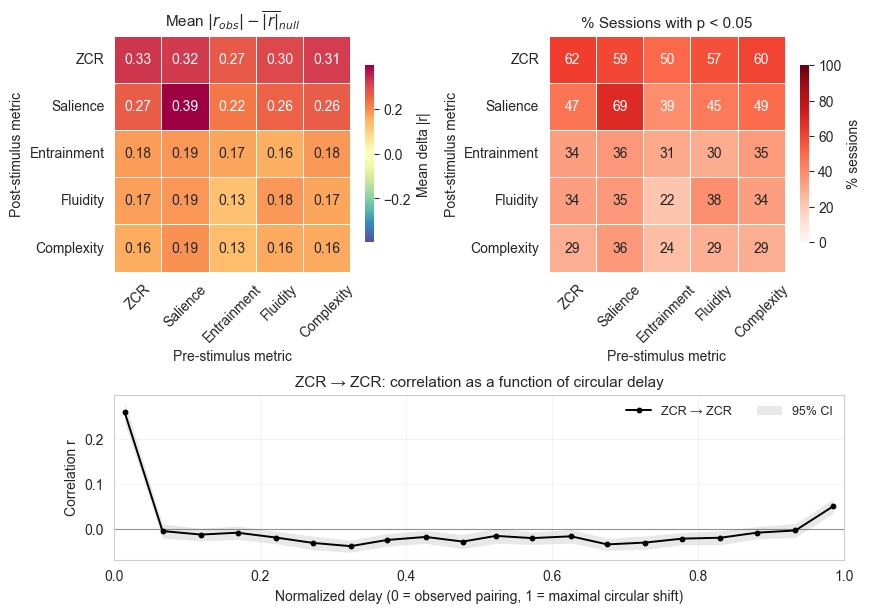

Saved combined figure: /Users/cbc/Documents/GitHub/fufo/notebook/DavideMomi/Revision/State_Dependent_Brain_Stimulation-main/results/figures/Supplementary_Trial_shift_null_5MOIs_SEEG_combined.png
Sessions contributing to delay profile: 318


In [49]:
from matplotlib.gridspec import GridSpec

delta_abs_max = np.nanmax(np.abs(mean_delta_abs_r.values))
delta_abs_max = max(delta_abs_max, 0.05)

zcr_delay_records = []
target_pre_metric = 'zero_crossing_rate'
target_post_metric = 'zero_crossing_rate'

for (sub, run), session_df in df.groupby(['sub', 'run_is']):
    session_df = session_df.sort_values('trial_id').reset_index(drop=True)
    pivot = session_df.pivot_table(
        index='trial_id',
        columns='metric_name',
        values=['metric_value_pre', 'metric_value_post'],
        aggfunc='mean',
    )

    pre_key = ('metric_value_pre', target_pre_metric)
    post_key = ('metric_value_post', target_post_metric)

    if pre_key not in pivot.columns or post_key not in pivot.columns:
        continue

    pre_vals = pivot[pre_key].values
    post_vals = pivot[post_key].values

    mask = ~(np.isnan(pre_vals) | np.isnan(post_vals))
    pre_vals = pre_vals[mask]
    post_vals = post_vals[mask]
    n_trials = len(pre_vals)

    if n_trials < 3 or np.std(pre_vals) == 0 or np.std(post_vals) == 0:
        continue

    for shift in range(n_trials):
        aligned_pre = pre_vals if shift == 0 else np.roll(pre_vals, shift)

        if np.std(aligned_pre) == 0:
            continue

        r_shift, _ = pearsonr(aligned_pre, post_vals)
        zcr_delay_records.append({
            'sub': sub,
            'run_is': run,
            'shift': shift,
            'delay_fraction': shift / (n_trials - 1) if n_trials > 1 else 0.0,
            'r_value': r_shift,
        })

zcr_delay_df = pd.DataFrame(zcr_delay_records)
zcr_delay_df['delay_bin'] = pd.cut(
    zcr_delay_df['delay_fraction'],
    bins=np.linspace(0, 1, 21),
    include_lowest=True,
    labels=False,
 )

zcr_delay_profile = zcr_delay_df.groupby('delay_bin').agg(
    delay_fraction=('delay_fraction', 'mean'),
    mean_r=('r_value', 'mean'),
    std_r=('r_value', lambda x: x.std(ddof=1) if len(x) > 1 else 0.0),
    n_points=('r_value', 'size'),
).dropna().reset_index(drop=True)
zcr_delay_profile['ci95_halfwidth'] = 1.96 * zcr_delay_profile['std_r'] / np.sqrt(zcr_delay_profile['n_points'].clip(lower=1))

fig = plt.figure(figsize=(8.8, 6.2))
grid = GridSpec(2, 2, figure=fig, height_ratios=[1.0, 0.7])
ax_heatmap_1 = fig.add_subplot(grid[0, 0])
ax_heatmap_2 = fig.add_subplot(grid[0, 1])
ax_delay = fig.add_subplot(grid[1, :])

sns.heatmap(
    mean_delta_abs_r,
    annot=True,
    fmt='.2f',
    cmap='Spectral_r',
    center=0,
    vmin=-delta_abs_max,
    vmax=delta_abs_max,
    cbar_kws={'label': 'Mean delta |r|', 'shrink': 0.75},
    linewidths=0.5,
    square=True,
    ax=ax_heatmap_1,
 )
ax_heatmap_1.set_title('Mean $|r_{obs}| - \overline{|r|}_{null}$', fontsize=11)
ax_heatmap_1.set_xlabel('Pre-stimulus metric', fontsize=10)
ax_heatmap_1.set_ylabel('Post-stimulus metric', fontsize=10)
ax_heatmap_1.tick_params(axis='x', rotation=45)
ax_heatmap_1.tick_params(axis='y', rotation=0)

sns.heatmap(
    pct_significant,
    annot=True,
    fmt='.0f',
    cmap='Reds',
    vmin=0,
    vmax=100,
    cbar_kws={'label': '% sessions', 'shrink': 0.75},
    linewidths=0.5,
    square=True,
    ax=ax_heatmap_2,
 )
ax_heatmap_2.set_title('% Sessions with p < 0.05', fontsize=11)
ax_heatmap_2.set_xlabel('Pre-stimulus metric', fontsize=10)
ax_heatmap_2.set_ylabel('Post-stimulus metric', fontsize=10)
ax_heatmap_2.tick_params(axis='x', rotation=45)
ax_heatmap_2.tick_params(axis='y', rotation=0)

ax_delay.plot(
    zcr_delay_profile['delay_fraction'],
    zcr_delay_profile['mean_r'],
    color='black',
    linewidth=1.4,
    marker='o',
    markersize=3.2,
    label='ZCR → ZCR',
)
ax_delay.fill_between(
    zcr_delay_profile['delay_fraction'],
    zcr_delay_profile['mean_r'] - zcr_delay_profile['ci95_halfwidth'],
    zcr_delay_profile['mean_r'] + zcr_delay_profile['ci95_halfwidth'],
    color='0.5',
    alpha=0.18,
    linewidth=0,
    label='95% CI',
)
ax_delay.axhline(0, color='black', linewidth=0.8, alpha=0.4)
ax_delay.set_xlim(0, 1)
ax_delay.set_xlabel('Normalized delay (0 = observed pairing, 1 = maximal circular shift)', fontsize=10)
ax_delay.set_ylabel('Correlation r', fontsize=10)
ax_delay.set_title('ZCR → ZCR: correlation as a function of circular delay', fontsize=11)
ax_delay.legend(frameon=False, ncol=2, fontsize=9, loc='upper right')
ax_delay.grid(alpha=0.2)

plt.tight_layout()

combined_fig_path_png = results_fig_path / 'Supplementary_Trial_shift_null_5MOIs_SEEG_combined.png'
plt.savefig(combined_fig_path_png, dpi=300, bbox_inches='tight', transparent=True)
plt.show()

print(f'Saved combined figure: {combined_fig_path_png}')
print(f'Sessions contributing to delay profile: {zcr_delay_df.groupby(["sub", "run_is"]).ngroups}')